<a href="https://colab.research.google.com/github/agrawalreva/idx-exchange-ds34/blob/main/EDA_for_Set_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R²: -1.0637314540586535
MAE: 2836551.070043096
RMSE: 3514028.2067980007


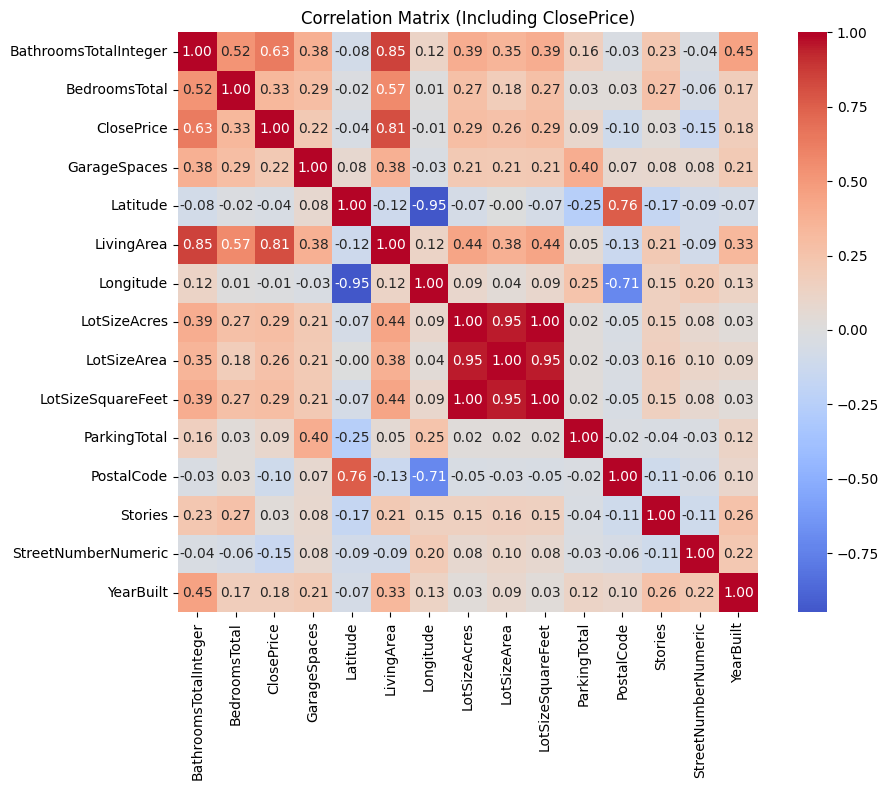

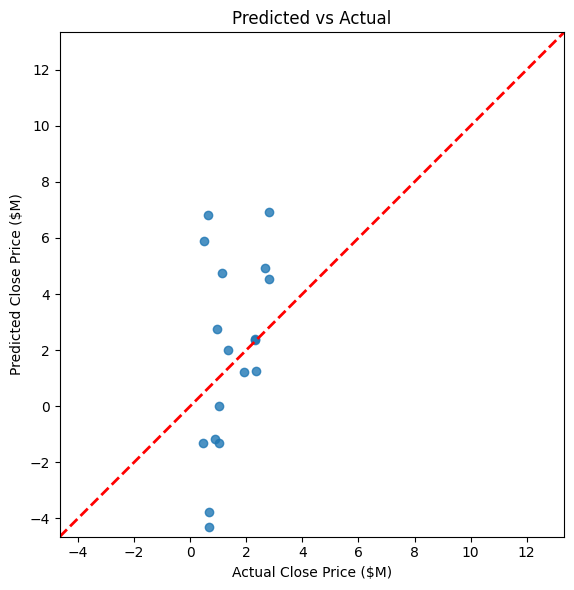

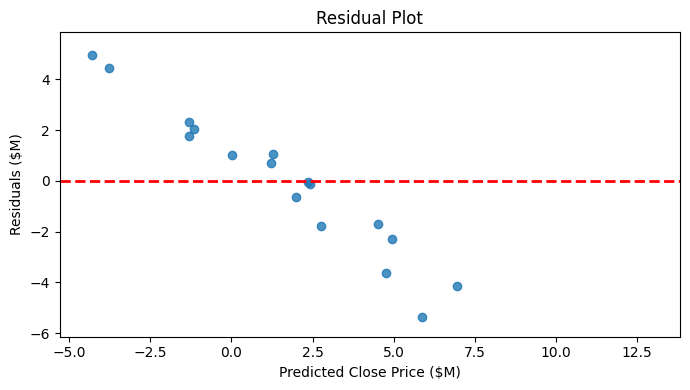

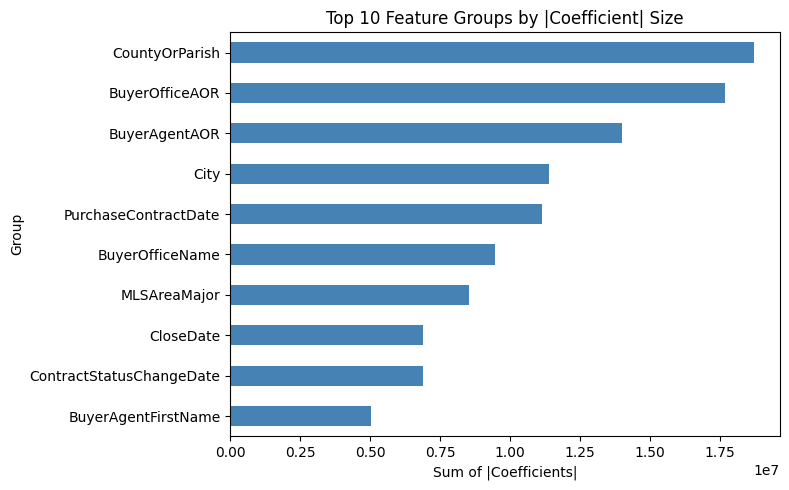

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleanedCRMLSSold202508_filled.csv", nrows=100).dropna(subset=["ClosePrice"])
y = df["ClosePrice"]
X = df.drop(columns=["ClosePrice"])

cat_cols = X.select_dtypes(include=["object", "category"]).columns
for c in cat_cols:
    top_vals = X[c].value_counts(dropna=False).nlargest(15).index
    X[c] = np.where(X[c].isin(top_vals), X[c], "Other")

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
coef_df["Group"] = coef_df["Feature"].str.split("_").str[0]
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
group_importance = coef_df.groupby("Group")["AbsCoef"].sum().sort_values(ascending=False)

num_cols = sorted(df.select_dtypes(include=[np.number]).columns)
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
    plt.title("Correlation Matrix (Including ClosePrice)")
    plt.tight_layout()
    plt.show()

y_test_m = y_test.to_numpy().astype(float) / 1e6
y_pred_m = y_pred.astype(float) / 1e6
residuals_m = (y_test.to_numpy().astype(float) - y_pred.astype(float)) / 1e6

qa, qb = np.quantile(np.concatenate([y_test_m, y_pred_m]), [0.02, 0.98])
xmin, xmax = qa, qb
ymin, ymax = qa, qb
mask = (y_test_m >= xmin) & (y_test_m <= xmax) & (y_pred_m >= ymin) & (y_pred_m <= ymax)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_m[mask], y_pred_m[mask], alpha=0.8)
plt.plot([xmin, xmax], [xmin, xmax], "r--", linewidth=2)
plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Actual Close Price ($M)"); plt.ylabel("Predicted Close Price ($M)")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

qx1, qx2 = np.quantile(y_pred_m, [0.02, 0.98])
qy1, qy2 = np.quantile(residuals_m, [0.02, 0.98])
mask_r = (y_pred_m >= qx1) & (y_pred_m <= qx2) & (residuals_m >= qy1) & (residuals_m <= qy2)

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_m[mask_r], residuals_m[mask_r], alpha=0.8)
plt.axhline(0, color="r", linestyle="--", linewidth=2)
plt.xlim(qx1, qx2); plt.ylim(qy1, qy2)
plt.xlabel("Predicted Close Price ($M)"); plt.ylabel("Residuals ($M)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
group_importance.head(10).iloc[::-1].plot(kind="barh", color="steelblue")
plt.title("Top 10 Feature Groups by |Coefficient| Size")
plt.xlabel("Sum of |Coefficients|")
plt.tight_layout()
plt.show()

#TERRIBLE RESULTS
